# 02_Data_Preprocessing

Notebook này bao phủ phần tiền xử lý dữ liệu chi tiết, xử lý theo từng file CSV, tích hợp dữ liệu đa bảng và build `master_orders`.

## ROADMAP

- C1 Setup: Khởi tạo Spark, load raw tables, chuẩn hóa schema.
- C2 File-by-file Clean: Xử lý missing/invalid/duplicate cho từng bảng.
- C3 Aggregate + Join: Aggregate các bảng 1-n và build `master_orders` ở grain order-level.
- C4 Integrity Check: Kiểm tra row explosion và quality metrics sau join.
- C5 Materialization: Lưu parquet theo lớp `silver` và `gold`, chốt catalog downstream.


**[C1-1] Import thư viện và cấu hình môi trường**

- Import các thư viện tiêu chuẩn: `pathlib`, `os`, `sys`, `warnings`.
- Import `pandas`, `numpy`, `matplotlib` để thao tác dữ liệu và vẽ biểu đồ.
- Import PySpark: `SparkSession`, `DataFrame`, `functions as F`, `Window` để xử lý dữ liệu phân tán.
- Cấu hình `warnings`, `pandas display` và style `matplotlib` để output gọn gàng hơn.


In [35]:
# Command 17 - Khởi tạo lại môi trường preprocessing theo hướng file-by-file
from pathlib import Path
import os
import sys
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
plt.style.use("seaborn-v0_8-whitegrid")


**[C1-2] Khởi tạo SparkSession**

- Lấy đường dẫn Python đang chạy (`sys.executable`) để đảm bảo PySpark dùng đúng interpreter.
- Dừng session cũ nếu tồn tại (`getActiveSession().stop()`) để tránh xung đột.
- Tạo SparkSession mới với config:
  - `local[2]`: chạy cục bộ 2 threads.
  - `spark.driver.memory = 4g`: cấp 4GB RAM cho driver.
  - `spark.sql.shuffle.partitions = 16`: giới hạn số partition khi shuffle (phù hợp dữ liệu nhỏ/trung bình).
  - `spark.sql.session.timeZone = UTC`: chuẩn hóa timezone.


In [36]:

python_exec = sys.executable
os.environ["PYSPARK_PYTHON"] = python_exec
os.environ["PYSPARK_DRIVER_PYTHON"] = python_exec

active_spark = SparkSession.getActiveSession()
if active_spark is not None:
    active_spark.stop()

spark = (
    SparkSession.builder
    .appName("Nhom03_Olist_Preprocessing") # type: ignore
    .master("local[2]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.python.worker.reuse", "false")
    .config("spark.pyspark.python", python_exec)
    .config("spark.pyspark.driver.python", python_exec)
    .config("spark.executorEnv.PYSPARK_PYTHON", python_exec)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")


26/04/03 00:12:12 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


**[C1-3] Thiết lập đường dẫn và nạp raw tables**

- `PROJECT_ROOT`: tự động xác định gốc dự án (kiểm tra xem đang chạy trong folder `notebooks/` hay không).
- Tạo cấu trúc thư mục `data/processed/bronze|silver|gold` nếu chưa có.
- `TABLE_FILES`: ánh xạ tên bảng → tên file CSV trong `data/raw/`.
- Dùng **dict comprehension** để đọc toàn bộ 9 file CSV một lúc với `inferSchema=True`.
  Sau bước này `raw_tables` là một dict `{tên_bảng: DataFrame}`.


In [37]:

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
BRONZE_DIR = PROCESSED_DIR / "bronze"
SILVER_DIR = PROCESSED_DIR / "silver"
GOLD_DIR = PROCESSED_DIR / "gold"
for output_dir in [PROCESSED_DIR, BRONZE_DIR, SILVER_DIR, GOLD_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

TABLE_FILES = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

raw_tables = {name: spark.read.option("header", True).option("inferSchema", True).csv(str(DATA_DIR / file_name)) for name, file_name in TABLE_FILES.items()}


**[C1-4] Chuẩn hóa schema cơ bản (type casting & rename)**

- `products_norm`: sửa lỗi typo cột `product_name_lenght` → `product_name_length`.
- `orders_norm`: ép kiểu 5 cột timestamp từ string → `TimestampType` bằng `F.to_timestamp()`.
- `order_items_norm`: ép kiểu `price`, `freight_value` → `DoubleType` để tính toán chính xác.
- `order_payments_norm`: ép `payment_sequential`, `payment_installments` → `IntegerType`; `payment_value` → `DoubleType`.
- `order_reviews_norm`: ép `review_score` → `IntegerType`; 2 cột ngày → `TimestampType`.
- `customers_norm`, `sellers_norm`, `geolocation_norm`: chuẩn hóa city (lowercase + trim) và state (uppercase + trim).
- Cuối cùng gom lại thành dict `normalized_tables` — điểm bắt đầu cho toàn bộ bước cleaning.


In [38]:

products_norm = (
    raw_tables["products"]
    .withColumnRenamed("product_name_lenght", "product_name_length")
    .withColumnRenamed("product_description_lenght", "product_description_length")
)

orders_norm = (
    raw_tables["orders"]
    .withColumn("order_purchase_timestamp", F.to_timestamp("order_purchase_timestamp"))
    .withColumn("order_approved_at", F.to_timestamp("order_approved_at"))
    .withColumn("order_delivered_carrier_date", F.to_timestamp("order_delivered_carrier_date"))
    .withColumn("order_delivered_customer_date", F.to_timestamp("order_delivered_customer_date"))
    .withColumn("order_estimated_delivery_date", F.to_timestamp("order_estimated_delivery_date"))
)

order_items_norm = (
    raw_tables["order_items"]
    .withColumn("shipping_limit_date", F.to_timestamp("shipping_limit_date"))
    .withColumn("price", F.col("price").cast("double"))
    .withColumn("freight_value", F.col("freight_value").cast("double"))
)

order_payments_norm = (
    raw_tables["order_payments"]
    .withColumn("payment_sequential", F.col("payment_sequential").cast("int"))
    .withColumn("payment_installments", F.col("payment_installments").cast("int"))
    .withColumn("payment_value", F.col("payment_value").cast("double"))
)

order_reviews_norm = (
    raw_tables["order_reviews"]
    .withColumn("review_score", F.col("review_score").cast("int"))
    .withColumn("review_creation_date", F.to_timestamp("review_creation_date"))
    .withColumn("review_answer_timestamp", F.to_timestamp("review_answer_timestamp"))
)

customers_norm = raw_tables["customers"].withColumn("customer_city", F.lower(F.trim(F.col("customer_city")))).withColumn("customer_state", F.upper(F.trim(F.col("customer_state"))))
sellers_norm = raw_tables["sellers"].withColumn("seller_city", F.lower(F.trim(F.col("seller_city")))).withColumn("seller_state", F.upper(F.trim(F.col("seller_state"))))
geolocation_norm = raw_tables["geolocation"].withColumn("geolocation_city", F.lower(F.trim(F.col("geolocation_city")))).withColumn("geolocation_state", F.upper(F.trim(F.col("geolocation_state"))))

normalized_tables = {
    "customers": customers_norm,
    "orders": orders_norm,
    "order_items": order_items_norm,
    "order_payments": order_payments_norm,
    "order_reviews": order_reviews_norm,
    "products": products_norm,
    "sellers": sellers_norm,
    "geolocation": geolocation_norm,
    "category_translation": raw_tables["category_translation"],
}


**[C1-5] Định nghĩa các helper functions tái sử dụng**

| Hàm                            | Mục đích                                                                  |
| ------------------------------ | ------------------------------------------------------------------------- |
| `build_null_profile(df)`       | Đếm số null và tỉ lệ null cho từng cột, trả về DataFrame có thể `.show()` |
| `median_fill(df, col_name)`    | Dùng `approxQuantile` (median) để fill null cho cột số                    |
| `show_clean_summary(df, name)` | In thông tin tổng hợp: row count, column count, null profile              |
| `to_pandas_small(df, limit)`   | Chuyển tối đa `limit` dòng về pandas DataFrame để vẽ biểu đồ              |
| `plot_bar_from_spark(df, ...)` | Vẽ bar chart từ Spark DataFrame (hỗ trợ cả horizontal và vertical)        |


In [39]:


def build_null_profile(df: DataFrame) -> DataFrame:
    total_rows = df.count()
    exprs = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns]
    null_counts = df.agg(*exprs)
    stacked_expr = "stack({0}, {1}) as (column_name, null_count)".format(
        len(df.columns),
        ", ".join([f"'{c}', `{c}`" for c in df.columns]),
    )
    return (
        null_counts
        .selectExpr(stacked_expr)
        .withColumn("row_count", F.lit(total_rows))
        .withColumn("null_ratio", F.when(F.col("row_count") > 0, F.col("null_count") / F.col("row_count")).otherwise(F.lit(0.0)))
        .orderBy(F.desc("null_ratio"), F.desc("null_count"))
    )


def median_fill(df: DataFrame, col_name: str) -> DataFrame:
    median_value = df.approxQuantile(col_name, [0.5], 0.001)[0]
    return df.withColumn(col_name, F.coalesce(F.col(col_name), F.lit(median_value)))


def show_clean_summary(df: DataFrame, table_name: str) -> None:
    print("=" * 100)
    print(f"CLEAN TABLE: {table_name}")
    print(f"ROW COUNT: {df.count():,} | COLUMN COUNT: {len(df.columns)}")
    build_null_profile(df).show(len(df.columns), truncate=False)


def to_pandas_small(df: DataFrame, limit: int = 1000) -> pd.DataFrame:
    return df.limit(limit).toPandas()


def plot_bar_from_spark(df: DataFrame, x_col: str, y_col: str, title: str, xlabel: str, ylabel: str, limit: int = 20, horizontal: bool = False) -> None:
    pdf = to_pandas_small(df, limit)
    if pdf.empty:
        print(f"No data available for chart: {title}")
        return
    plt.figure(figsize=(12, 5))
    if horizontal:
        plt.barh(pdf[x_col].astype(str), pdf[y_col])
        plt.gca().invert_yaxis()
    else:
        plt.bar(pdf[x_col].astype(str), pdf[y_col])
        plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


print(f"Spark version: {spark.version}")
print(f"Python executable: {python_exec}")
print(f"DATA_DIR: {DATA_DIR}")


Spark version: 3.5.8
Python executable: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/.venv/bin/python
DATA_DIR: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw


**[C2] Mốc bắt đầu xử lý file-by-file**

Cell này đánh dấu bắt đầu giai đoạn làm sạch riêng từng file CSV.
Mỗi file sẽ có block logic độc lập, giúp:

- Dễ debug từng bảng mà không ảnh hưởng bảng khác.
- Dễ đọc và kiểm tra kết quả sau từng bước.


In [40]:
# Command 18 - Helper preprocessing theo từng file CSV
print("Sẵn sàng xử lý dữ liệu theo từng file CSV riêng biệt")

Sẵn sàng xử lý dữ liệu theo từng file CSV riêng biệt


### 4.4.2. Xử lý giá trị thiếu

### 4.4.3. Xử lý dữ liệu lỗi và không hợp lệ

### 4.4.4. Loại bỏ hoặc gom nhóm dữ liệu trùng lặp

Các cell dưới đây xử lý riêng từng file CSV để dễ đọc và dễ kiểm tra.


#### File CSV: `customers`


**[Customers] Làm sạch bảng `customers`**

- `dropDuplicates(['customer_id'])`: loại bỏ dòng trùng theo khóa chính.
- `F.lower(F.trim(col('customer_city')))`: chuẩn hóa tên thành phố về chữ thường, bỏ khoảng trắng thừa.
- `F.upper(F.trim(col('customer_state')))`: chuẩn hóa mã tiểu bang về chữ hoa.
- `show_clean_summary()`: kiểm tra null profile sau làm sạch.


In [41]:
# Làm sạch riêng file customers
customers_clean = (
    normalized_tables["customers"]
    .dropDuplicates(["customer_id"])
    .withColumn("customer_city", F.lower(F.trim(F.col("customer_city"))))
    .withColumn("customer_state", F.upper(F.trim(F.col("customer_state"))))
)
show_clean_summary(customers_clean, "customers_clean")


CLEAN TABLE: customers_clean
ROW COUNT: 99,441 | COLUMN COUNT: 5
+------------------------+----------+---------+----------+
|column_name             |null_count|row_count|null_ratio|
+------------------------+----------+---------+----------+
|customer_id             |0         |99441    |0.0       |
|customer_unique_id      |0         |99441    |0.0       |
|customer_zip_code_prefix|0         |99441    |0.0       |
|customer_city           |0         |99441    |0.0       |
|customer_state          |0         |99441    |0.0       |
+------------------------+----------+---------+----------+



#### File CSV: `orders`


**[Orders] Làm sạch bảng `orders`**

- `dropDuplicates(['order_id'])`: đảm bảo mỗi đơn hàng chỉ xuất hiện 1 lần.
- Tạo **missing flags** (cột `is_missing_*`): đánh dấu nhị phân (0/1) cho các cột timestamp có thể null.
  Giúp giữ lại thông tin _thiếu dữ liệu_ dù đã fill sau đó.
- `order_approved_at_filled`: dùng `F.coalesce()` để fill null bằng `order_purchase_timestamp`
  (giả định: nếu thiếu ngày duyệt, lấy ngày đặt hàng làm xấp xỉ).


In [42]:
# Làm sạch riêng file orders
orders_clean = (
    normalized_tables["orders"]
    .dropDuplicates(["order_id"])
    .withColumn("is_missing_order_approved_at", F.col("order_approved_at").isNull().cast("int"))
    .withColumn("is_missing_delivered_carrier_date", F.col("order_delivered_carrier_date").isNull().cast("int"))
    .withColumn("is_missing_delivered_customer_date", F.col("order_delivered_customer_date").isNull().cast("int"))
    .withColumn("order_approved_at_filled", F.coalesce(F.col("order_approved_at"), F.col("order_purchase_timestamp")))
)
show_clean_summary(orders_clean, "orders_clean")


CLEAN TABLE: orders_clean
ROW COUNT: 99,441 | COLUMN COUNT: 12
+----------------------------------+----------+---------+---------------------+
|column_name                       |null_count|row_count|null_ratio           |
+----------------------------------+----------+---------+---------------------+
|order_delivered_customer_date     |2965      |99441    |0.02981667521444877  |
|order_delivered_carrier_date      |1783      |99441    |0.017930229985619613 |
|order_approved_at                 |160       |99441    |0.0016089942780140988|
|order_id                          |0         |99441    |0.0                  |
|customer_id                       |0         |99441    |0.0                  |
|order_status                      |0         |99441    |0.0                  |
|order_purchase_timestamp          |0         |99441    |0.0                  |
|order_estimated_delivery_date     |0         |99441    |0.0                  |
|is_missing_order_approved_at      |0         |99441    |

#### File CSV: `order_items`


**[Order Items] Làm sạch bảng `order_items`**

- `dropDuplicates(['order_id', 'order_item_id'])`: khóa phức hợp cho bảng item-level.
- Tạo `is_invalid_price`: đánh dấu khi `price <= 0` (giá không hợp lệ).
- Tạo `is_invalid_freight_value`: đánh dấu khi `freight_value < 0` (phí âm vô lý).
- Đặt giá trị không hợp lệ về `None` và giữ nguyên NULL — **không fill ở đây**.
  Median imputation sẽ được thực hiện **sau khi split** (fit on train only) để tránh data leakage.


In [43]:
# Làm sạch riêng file order_items
order_items_clean = (
    normalized_tables["order_items"]
    .dropDuplicates(["order_id", "order_item_id"])
    .withColumn("is_invalid_price", F.when(F.col("price") <= 0, 1).otherwise(0))
    .withColumn("is_invalid_freight_value", F.when(F.col("freight_value") < 0, 1).otherwise(0))
    .withColumn("price", F.when(F.col("price") <= 0, None).otherwise(F.col("price")))
    .withColumn("freight_value", F.when(F.col("freight_value") < 0, None).otherwise(F.col("freight_value")))
)
# Không gọi median_fill ở đây — imputation sẽ thực hiện sau split
show_clean_summary(order_items_clean, "order_items_clean")

CLEAN TABLE: order_items_clean
ROW COUNT: 112,650 | COLUMN COUNT: 9
+------------------------+----------+---------+----------+
|column_name             |null_count|row_count|null_ratio|
+------------------------+----------+---------+----------+
|order_id                |0         |112650   |0.0       |
|order_item_id           |0         |112650   |0.0       |
|product_id              |0         |112650   |0.0       |
|seller_id               |0         |112650   |0.0       |
|shipping_limit_date     |0         |112650   |0.0       |
|price                   |0         |112650   |0.0       |
|freight_value           |0         |112650   |0.0       |
|is_invalid_price        |0         |112650   |0.0       |
|is_invalid_freight_value|0         |112650   |0.0       |
+------------------------+----------+---------+----------+



#### File CSV: `order_payments`


**[Order Payments] Làm sạch bảng `order_payments`**

- `dropDuplicates()` (không truyền cột): loại bỏ dòng hoàn toàn trùng lặp.
- `is_invalid_payment_value`: đánh dấu khi `payment_value <= 0`.
- Đặt giá trị không hợp lệ về `None` và giữ nguyên NULL — **không fill ở đây**.
  Median imputation sẽ được thực hiện **sau khi split** (fit on train only) để tránh data leakage.


In [44]:
# Làm sạch riêng file order_payments
order_payments_clean = (
    normalized_tables["order_payments"]
    .dropDuplicates()
    .withColumn("is_invalid_payment_value", F.when(F.col("payment_value") <= 0, 1).otherwise(0))
    .withColumn("payment_value", F.when(F.col("payment_value") <= 0, None).otherwise(F.col("payment_value")))
)
# Không gọi median_fill ở đây — imputation sẽ thực hiện sau split
show_clean_summary(order_payments_clean, "order_payments_clean")

CLEAN TABLE: order_payments_clean
ROW COUNT: 103,886 | COLUMN COUNT: 6
+------------------------+----------+---------+--------------------+
|column_name             |null_count|row_count|null_ratio          |
+------------------------+----------+---------+--------------------+
|payment_value           |9         |103886   |8.663342510059104E-5|
|order_id                |0         |103886   |0.0                 |
|payment_sequential      |0         |103886   |0.0                 |
|payment_type            |0         |103886   |0.0                 |
|payment_installments    |0         |103886   |0.0                 |
|is_invalid_payment_value|0         |103886   |0.0                 |
+------------------------+----------+---------+--------------------+



#### File CSV: `order_reviews`


**[Order Reviews] Làm sạch bảng `order_reviews`**

- Bảng reviews phức tạp hơn vì một `review_id` có thể có nhiều dòng (nhiều lần update).
- `Window.partitionBy('review_id').orderBy(review_answer_timestamp.desc_nulls_last())`:
  xếp hạng các dòng trong cùng review_id theo timestamp mới nhất.
- `row_number().over(window) == 1`: chỉ giữ dòng mới nhất của mỗi review_id.
- Missing flags cho `review_comment_title` và `review_comment_message` (tỉ lệ null rất cao ~88%).
- Fill text null bằng chuỗi rỗng `''` để các bước xử lý text downstream không bị lỗi.
- `review_score` ngoài miền [1-5] bị đặt về `None`.


In [45]:
# Làm sạch riêng file order_reviews
review_window = Window.partitionBy("review_id").orderBy(
    F.col("review_answer_timestamp").desc_nulls_last(),
    F.col("review_creation_date").desc_nulls_last(),
)

reviews_clean = (
    normalized_tables["order_reviews"]
    .withColumn("is_missing_review_comment_title", F.col("review_comment_title").isNull().cast("int"))
    .withColumn("is_missing_review_comment_message", F.col("review_comment_message").isNull().cast("int"))
    .withColumn("review_comment_title_filled", F.coalesce(F.col("review_comment_title"), F.lit("")))
    .withColumn("review_comment_message_filled", F.coalesce(F.col("review_comment_message"), F.lit("")))
    .withColumn("review_score", F.when(F.col("review_score").between(1, 5), F.col("review_score")).otherwise(None))
    .withColumn("review_row_number", F.row_number().over(review_window))
    .filter(F.col("review_row_number") == 1)
    .drop("review_row_number")
)
show_clean_summary(reviews_clean, "reviews_clean")


CLEAN TABLE: reviews_clean
ROW COUNT: 102,958 | COLUMN COUNT: 11
+---------------------------------+----------+---------+--------------------+
|column_name                      |null_count|row_count|null_ratio          |
+---------------------------------+----------+---------+--------------------+
|review_comment_title             |91024     |102958   |0.8840886575108297  |
|review_comment_message           |62190     |102958   |0.6040327123681501  |
|review_creation_date             |8395      |102958   |0.08153810291575206 |
|review_answer_timestamp          |8367      |102958   |0.08126614736105985 |
|review_score                     |4548      |102958   |0.04417335224071952 |
|order_id                         |2176      |102958   |0.021134831678937042|
|review_id                        |1         |102958   |9.712698381864449E-6|
|is_missing_review_comment_title  |0         |102958   |0.0                 |
|is_missing_review_comment_message|0         |102958   |0.0                 |

#### File CSV: `products`


**[Products] Làm sạch bảng `products`**

- `dropDuplicates(['product_id'])`: khóa chính product.
- `product_category_name` null → fill bằng `'unknown'` (giữ nguyên hàng, tránh mất dữ liệu).
- `product_photos_qty` null → fill bằng `0` (hợp lý: không có ảnh).
- Vòng `for` qua 6 cột số (weight, dimensions, text lengths):
  1. Tạo `is_missing_*` flag.
  2. Đặt giá trị `<= 0` về `None` (kích thước âm/bằng 0 là vô lý).
  3. Fill null bằng trung vị.


In [46]:
# Làm sạch riêng file products
products_clean = (
    normalized_tables["products"]
    .dropDuplicates(["product_id"])
    .withColumn("is_missing_product_category_name", F.col("product_category_name").isNull().cast("int"))
    .withColumn("product_category_name", F.coalesce(F.col("product_category_name"), F.lit("unknown")))
    .withColumn("product_photos_qty", F.coalesce(F.col("product_photos_qty"), F.lit(0)))
)

for numeric_col in [
    "product_name_length",
    "product_description_length",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
]:
    products_clean = products_clean.withColumn(f"is_missing_{numeric_col}", F.col(numeric_col).isNull().cast("int"))
    products_clean = products_clean.withColumn(numeric_col, F.when(F.col(numeric_col) <= 0, None).otherwise(F.col(numeric_col)))
    products_clean = median_fill(products_clean, numeric_col)

show_clean_summary(products_clean, "products_clean")


CLEAN TABLE: products_clean
ROW COUNT: 32,951 | COLUMN COUNT: 16
+-------------------------------------+----------+---------+----------+
|column_name                          |null_count|row_count|null_ratio|
+-------------------------------------+----------+---------+----------+
|product_id                           |0         |32951    |0.0       |
|product_category_name                |0         |32951    |0.0       |
|product_name_length                  |0         |32951    |0.0       |
|product_description_length           |0         |32951    |0.0       |
|product_photos_qty                   |0         |32951    |0.0       |
|product_weight_g                     |0         |32951    |0.0       |
|product_length_cm                    |0         |32951    |0.0       |
|product_height_cm                    |0         |32951    |0.0       |
|product_width_cm                     |0         |32951    |0.0       |
|is_missing_product_category_name     |0         |32951    |0.0       |

#### File CSV: `sellers`


**[Sellers] Làm sạch bảng `sellers`**

- `dropDuplicates(['seller_id'])`: đảm bảo mỗi seller xuất hiện 1 lần.
- Chuẩn hóa `seller_city` (lowercase + trim) và `seller_state` (uppercase + trim),
  tương tự như bảng customers để đảm bảo nhất quán khi join địa lý.


In [47]:
# Làm sạch riêng file sellers
sellers_clean = (
    normalized_tables["sellers"]
    .dropDuplicates(["seller_id"])
    .withColumn("seller_city", F.lower(F.trim(F.col("seller_city"))))
    .withColumn("seller_state", F.upper(F.trim(F.col("seller_state"))))
)
show_clean_summary(sellers_clean, "sellers_clean")


CLEAN TABLE: sellers_clean
ROW COUNT: 3,095 | COLUMN COUNT: 4
+----------------------+----------+---------+----------+
|column_name           |null_count|row_count|null_ratio|
+----------------------+----------+---------+----------+
|seller_id             |0         |3095     |0.0       |
|seller_zip_code_prefix|0         |3095     |0.0       |
|seller_city           |0         |3095     |0.0       |
|seller_state          |0         |3095     |0.0       |
+----------------------+----------+---------+----------+



#### File CSV: `geolocation`


**[Geolocation] Làm sạch bảng `geolocation`**

- `dropDuplicates()`: loại bỏ tọa độ trùng hoàn toàn (bảng geolocation rất nhiều bản ghi lặp).
- `groupBy(zip_code, city, state).agg(avg_lat, avg_lng, count)`:
  tạo bảng `geolocation_zip_city_state_df` với tọa độ trung bình cho mỗi tổ hợp zip+city+state.
  Bảng này sẽ được dùng để enrich thông tin địa lý cho customers ở bước join sau.


In [48]:
# Làm sạch riêng file geolocation
geolocation_clean = normalized_tables["geolocation"].dropDuplicates()
geolocation_zip_city_state_df = (
    geolocation_clean
    .groupBy("geolocation_zip_code_prefix", "geolocation_city", "geolocation_state")
    .agg(
        F.avg("geolocation_lat").alias("avg_lat"),
        F.avg("geolocation_lng").alias("avg_lng"),
        F.count("*").alias("geo_points"),
    )
)
show_clean_summary(geolocation_clean, "geolocation_clean")
geolocation_zip_city_state_df.show(10, truncate=False)


CLEAN TABLE: geolocation_clean


ROW COUNT: 738,332 | COLUMN COUNT: 5


+---------------------------+----------+---------+----------+
|column_name                |null_count|row_count|null_ratio|
+---------------------------+----------+---------+----------+
|geolocation_zip_code_prefix|0         |738332   |0.0       |
|geolocation_lat            |0         |738332   |0.0       |
|geolocation_lng            |0         |738332   |0.0       |
|geolocation_city           |0         |738332   |0.0       |
|geolocation_state          |0         |738332   |0.0       |
+---------------------------+----------+---------+----------+

+---------------------------+----------------+-----------------+-------------------+-------------------+----------+
|geolocation_zip_code_prefix|geolocation_city|geolocation_state|avg_lat            |avg_lng            |geo_points|
+---------------------------+----------------+-----------------+-------------------+-------------------+----------+
|1005                       |sao paulo       |SP               |-23.549487008784876|-46.63665

#### File CSV: `category_translation`


**[Category Translation] Làm sạch bảng `category_translation`**

- `dropDuplicates(['product_category_name'])`: đảm bảo mỗi tên danh mục tiếng Bồ chỉ có 1 bản dịch tiếng Anh.
- Bảng này nhỏ (71 dòng) và không có null, chỉ cần dedup là đủ.


In [49]:
# Làm sạch riêng file category_translation
category_translation_clean = normalized_tables["category_translation"].dropDuplicates(["product_category_name"])
show_clean_summary(category_translation_clean, "category_translation_clean")


CLEAN TABLE: category_translation_clean
ROW COUNT: 71 | COLUMN COUNT: 2
+-----------------------------+----------+---------+----------+
|column_name                  |null_count|row_count|null_ratio|
+-----------------------------+----------+---------+----------+
|product_category_name        |0         |71       |0.0       |
|product_category_name_english|0         |71       |0.0       |
+-----------------------------+----------+---------+----------+



**[C2-Summary] Gom tất cả bảng đã clean vào `clean_tables`**

- Tạo dict `clean_tables` tập hợp 9 DataFrame đã làm sạch.
- `clean_table_summary_pdf`: pandas DataFrame với grain 1 dòng = 1 bảng,
  chứa `row_count` và `column_count` sau preprocessing.
- Vẽ horizontal bar chart để trực quan hóa quy mô từng bảng.


          table_name  row_count  column_count
category_translation         71             2
           customers      99441             5
         geolocation     738332             5
         order_items     112650             9
      order_payments     103886             6
       order_reviews     102958            11
              orders      99441            12
            products      32951            16
             sellers       3095             4


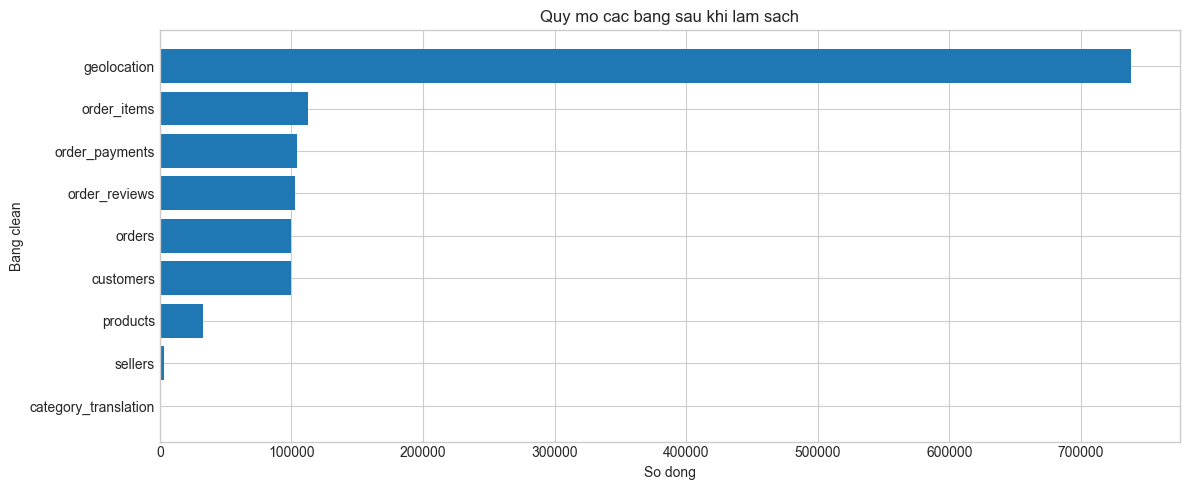

In [50]:
# Command 19 - Gom các bảng clean sau khi xử lý từng file
clean_tables = {
    "customers": customers_clean,
    "orders": orders_clean,
    "order_items": order_items_clean,
    "order_payments": order_payments_clean,
    "order_reviews": reviews_clean,
    "products": products_clean,
    "sellers": sellers_clean,
    "geolocation": geolocation_clean,
    "category_translation": category_translation_clean,
}

clean_table_summary_pdf = pd.DataFrame(
    [(name, df.count(), len(df.columns)) for name, df in clean_tables.items()],
    columns=["table_name", "row_count", "column_count"],
).sort_values("table_name").reset_index(drop=True)

print(clean_table_summary_pdf.to_string(index=False))

plt.figure(figsize=(12, 5))
_plot_df = clean_table_summary_pdf.sort_values("row_count", ascending=True)
plt.barh(_plot_df["table_name"], _plot_df["row_count"])
plt.title("Quy mo cac bang sau khi lam sach")
plt.xlabel("So dong")
plt.ylabel("Bang clean")
plt.tight_layout()
plt.show()


### 4.4.5. Chuẩn hóa timestamp, numeric fields và categorical fields


**[C3-1] Enrich và aggregate `order_items` về grain order-level**

- `order_items_enriched_df`: join `order_items_clean` với `products`, `category_translation`, `sellers`.
  Bổ sung tên danh mục tiếng Anh (`product_category_name_enriched`) từ bảng dịch.
- `order_items_order_level_df`: **groupBy order_id** để aggregate về grain order-level:
  - `items_per_order`: số item trong đơn.
  - `unique_products/sellers/categories_per_order`: đa dạng hóa đơn hàng.
  - `order_item_value`, `order_freight_value`: tổng giá trị và phí vận chuyển.
  - `order_gmv = item_value + freight_value`: gross merchandise value.
  - `seller_state_set`, `category_set`: tập hợp trạng thái seller và danh mục (dạng array).
- **Lý do phải aggregate trước khi join**: join trực tiếp bảng 1-n vào orders gây row explosion.


In [51]:
# Command 20 - Tạo aggregate hỗ trợ join từ từng file đã clean
order_items_enriched_df = (
    order_items_clean
    .join(products_clean, on="product_id", how="left")
    .join(category_translation_clean, on="product_category_name", how="left")
    .join(sellers_clean, on="seller_id", how="left")
    .withColumn(
        "product_category_name_enriched",
        F.coalesce(F.col("product_category_name_english"), F.col("product_category_name"), F.lit("unknown")),
    )
)

order_items_order_level_df = (
    order_items_enriched_df
    .groupBy("order_id")
    .agg(
        F.count("*").alias("items_per_order"),
        F.countDistinct("product_id").alias("unique_products_per_order"),
        F.countDistinct("seller_id").alias("unique_sellers_per_order"),
        F.countDistinct("product_category_name_enriched").alias("unique_categories_per_order"),
        F.sum("price").alias("order_item_value"),
        F.sum("freight_value").alias("order_freight_value"),
        F.avg("product_weight_g").alias("avg_product_weight_g"),
        F.collect_set("seller_state").alias("seller_state_set"),
        F.collect_set("product_category_name_enriched").alias("category_set"),
    )
    .withColumn("order_gmv", F.col("order_item_value") + F.col("order_freight_value"))
)



**[C3-2] Aggregate `order_payments` về grain order-level**

- `payments_order_level_df`: groupBy `order_id`, tổng hợp:
  - `payment_total_value`: tổng tiền thanh toán cho đơn hàng.
  - `max_payment_installments`: số kỳ trả góp tối đa (đặc trưng tín dụng).
  - `payment_record_count`: số giao dịch thanh toán (một đơn có thể thanh toán nhiều đợt).
  - `payment_type_set`: tập hợp các phương thức thanh toán (credit_card, boleto, v.v.).


In [52]:
payments_order_level_df = (
    order_payments_clean
    .groupBy("order_id")
    .agg(
        F.sum("payment_value").alias("payment_total_value"),
        F.max("payment_installments").alias("max_payment_installments"),
        F.count("*").alias("payment_record_count"),
        F.collect_set("payment_type").alias("payment_type_set"),
    )
)



**[C3-3] Aggregate `order_reviews` về grain order-level + summary**

- Tiền xử lý text review: lowercase + trim + collapse whitespace bằng `regexp_replace`.
- Tính `comment_length`: độ dài comment sau làm sạch (feature hữu ích cho NLP).
- GroupBy `order_id` lấy:
  - `review_score`: điểm đánh giá cao nhất (đối với đơn có nhiều review).
  - `has_review_comment`: flag có comment hay không.
  - `max_review_comment_length`: độ dài comment dài nhất.
  - `latest_review_creation_date`: ngày review gần nhất.
- In summary và vẽ biểu đồ so sánh row count các bảng aggregate.


                table_name  row_count
order_items_order_level_df      98666
   payments_order_level_df      99440
    reviews_order_level_df      99200


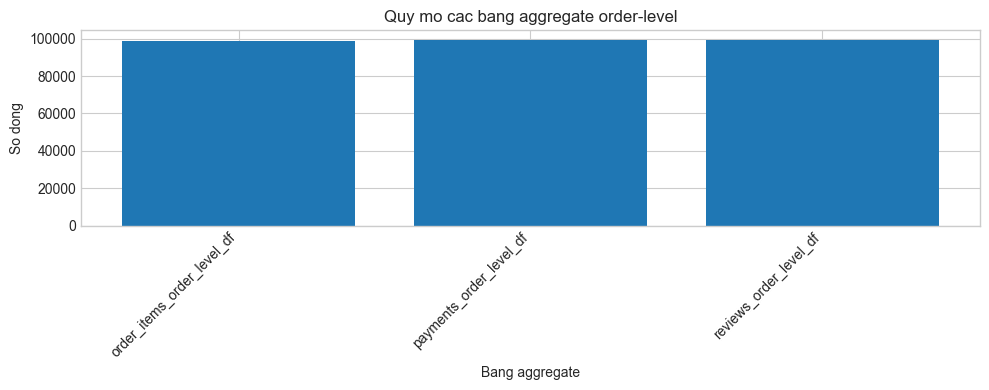

In [53]:
reviews_order_level_df = (
    reviews_clean
    .withColumn("review_comment_message_clean", F.lower(F.trim(F.regexp_replace(F.col("review_comment_message_filled"), r"\s+", " "))))
    .withColumn("comment_length", F.length(F.col("review_comment_message_clean")))
    .groupBy("order_id")
    .agg(
        F.max("review_score").alias("review_score"),
        F.max("is_missing_review_comment_message").alias("is_missing_review_comment_message"),
        F.max(F.when(F.col("comment_length") > 0, 1).otherwise(0)).alias("has_review_comment"),
        F.max("comment_length").alias("max_review_comment_length"),
        F.max("review_creation_date").alias("latest_review_creation_date"),
    )
)

support_table_summary_pdf = pd.DataFrame(
    [
        ("order_items_order_level_df", order_items_order_level_df.count()),
        ("payments_order_level_df", payments_order_level_df.count()),
        ("reviews_order_level_df", reviews_order_level_df.count()),
    ],
    columns=["table_name", "row_count"],
)
print(support_table_summary_pdf.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.bar(support_table_summary_pdf["table_name"], support_table_summary_pdf["row_count"])
plt.title("Quy mo cac bang aggregate order-level")
plt.xlabel("Bang aggregate")
plt.ylabel("So dong")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4.5. Tích hợp dữ liệu đa bảng


### 4.5.1. Thiết kế bảng `master_orders`

### 4.5.2. Join bảng khách hàng, đơn hàng và chi tiết đơn hàng

### 4.5.3. Join bảng review, payment, product và seller


**[C4-1] Enrich customers với tọa độ địa lý**

- `customer_geo_df`: từ `geolocation_zip_city_state_df` (đã aggregate), groupBy zip_code để lấy
  tọa độ trung bình (`avg_lat`, `avg_lng`) cho mỗi zip code prefix.
- `customers_enriched_df`: join `customers_clean` với `customer_geo_df` theo zip_code.
  Kết quả: mỗi customer có thêm tọa độ xấp xỉ để dùng cho phân tích địa lý.


In [54]:
# Command 21 - Build master_orders ở grain order-level
customer_geo_df = (
    geolocation_zip_city_state_df
    .groupBy("geolocation_zip_code_prefix")
    .agg(
        F.avg("avg_lat").alias("customer_zip_lat"),
        F.avg("avg_lng").alias("customer_zip_lng"),
    )
)

customers_enriched_df = (
    customers_clean
    .join(customer_geo_df, customers_clean["customer_zip_code_prefix"] == customer_geo_df["geolocation_zip_code_prefix"], how="left")
    .drop("geolocation_zip_code_prefix")
)



**[C4-2] Build bảng `master_orders` (grain: 1 dòng = 1 order)**

- Join chuỗi: `orders_clean` ← `customers_enriched_df` ← `order_items_order_level_df`
  ← `payments_order_level_df` ← `reviews_order_level_df`.
- Tất cả join dùng **left join** để không mất đơn hàng ngay cả khi thiếu review/payment.
- Thêm derived columns:
  - `same_state_any_seller_flag`: kiểm tra xem customer và ít nhất 1 seller có cùng tiểu bang không.
  - `order_has_review_flag`: đơn có review hay không.
  - `order_has_payment_flag`: đơn có payment hay không.
- Xác nhận: row count == distinct order_id count → không có row explosion.


In [55]:
master_orders_df = (
    orders_clean
    .join(customers_enriched_df, on="customer_id", how="left")
    .join(order_items_order_level_df, on="order_id", how="left")
    .join(payments_order_level_df, on="order_id", how="left")
    .join(reviews_order_level_df, on="order_id", how="left")
    .withColumn("same_state_any_seller_flag", F.when(F.array_contains(F.col("seller_state_set"), F.col("customer_state")), 1).otherwise(0))
    .withColumn("order_has_review_flag", F.col("review_score").isNotNull().cast("int"))
    .withColumn("order_has_payment_flag", F.col("payment_total_value").isNotNull().cast("int"))
)

print(f"master_orders rows: {master_orders_df.count():,}")
print(f"master_orders distinct order_id: {master_orders_df.select('order_id').distinct().count():,}")
master_orders_df.select(
    "order_id",
    "customer_unique_id",
    "order_status",
    "order_purchase_timestamp",
    "items_per_order",
    "order_gmv",
    "payment_total_value",
    "review_score",
).show(10, truncate=False)


master_orders rows: 99,441
master_orders distinct order_id: 99,441
+--------------------------------+--------------------------------+------------+------------------------+---------------+------------------+-------------------+------------+
|order_id                        |customer_unique_id              |order_status|order_purchase_timestamp|items_per_order|order_gmv         |payment_total_value|review_score|
+--------------------------------+--------------------------------+------------+------------------------+---------------+------------------+-------------------+------------+
|000229ec398224ef6ca0657da4fc703e|3818d81c6709e39d06b2738a8d3a2474|delivered   |2018-01-14 14:33:31     |1              |216.87            |216.87             |5           |
|00042b26cf59d7ce69dfabb4e55b4fd9|64b576fb70d441e8f1b2d7d446e483c5|delivered   |2017-02-04 13:57:51     |1              |218.04000000000002|218.04             |5           |
|00054e8431b9d7675808bcb819fb4a32|635d9ac1680f03288e72ada3a1035

**[C4-3] Kiểm tra tính toàn vẹn sau join (Integrity Check)**

- `join_step_pdf`: so sánh row count qua từng bước join, giúp phát hiện row explosion ngay.
- Biểu đồ bar: trực quan hóa row count — tất cả các bước phải ở gần mức 99,441 (số orders).
- `master_integrity_pdf`: các metric kiểm tra chất lượng master table:
  - `master_orders_row_count` phải bằng `master_orders_distinct_order_id`.
  - Null counts cho `order_gmv`, `payment_total_value`, `review_score` để xác định phủ dữ liệu.


              dataset_name  row_count
              orders_clean      99441
     customers_enriched_df      99441
order_items_order_level_df      98666
   payments_order_level_df      99440
    reviews_order_level_df      99200
          master_orders_df      99441


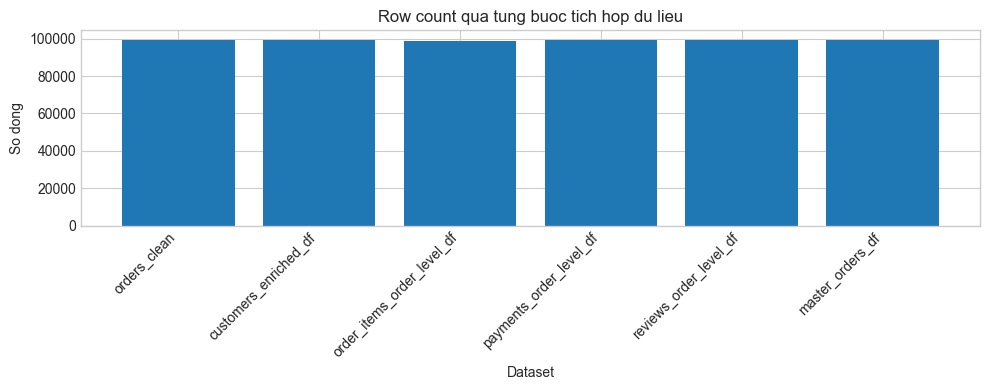

                           metric_name  metric_value
                orders_clean_row_count         99441
               master_orders_row_count         99441
       master_orders_distinct_order_id         99441
          master_orders_null_order_gmv           775
master_orders_null_payment_total_value             4
       master_orders_null_review_score          1274


In [56]:
# Command 22 - Kiểm tra tính toàn vẹn sau khi join và visualize quy mô qua từng bước
join_step_pdf = pd.DataFrame(
    [
        ("orders_clean", orders_clean.count()),
        ("customers_enriched_df", customers_enriched_df.count()),
        ("order_items_order_level_df", order_items_order_level_df.count()),
        ("payments_order_level_df", payments_order_level_df.count()),
        ("reviews_order_level_df", reviews_order_level_df.count()),
        ("master_orders_df", master_orders_df.count()),
    ],
    columns=["dataset_name", "row_count"],
)
print(join_step_pdf.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.bar(join_step_pdf["dataset_name"], join_step_pdf["row_count"])
plt.title("Row count qua tung buoc tich hop du lieu")
plt.xlabel("Dataset")
plt.ylabel("So dong")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

master_integrity_pdf = pd.DataFrame(
    [
        ("orders_clean_row_count", orders_clean.count()),
        ("master_orders_row_count", master_orders_df.count()),
        ("master_orders_distinct_order_id", master_orders_df.select("order_id").distinct().count()),
        ("master_orders_null_order_gmv", master_orders_df.filter(F.col("order_gmv").isNull()).count()),
        ("master_orders_null_payment_total_value", master_orders_df.filter(F.col("payment_total_value").isNull()).count()),
        ("master_orders_null_review_score", master_orders_df.filter(F.col("review_score").isNull()).count()),
    ],
    columns=["metric_name", "metric_value"],
)
print(master_integrity_pdf.to_string(index=False))


### Bảng phân tích trung gian phục vụ downstream


**[C5-1] Bảng phân tích customer-level (`customer_level_analytical_df`)**

- GroupBy `customer_unique_id` (không phải `customer_id`!) để tổng hợp hành vi mua hàng:
  - `total_orders`, `total_gmv`: tổng số đơn và giá trị.
  - `last/first_order_ts`: timestamp đơn hàng đầu và cuối → tính tenure.
  - `avg_items_per_order`: số item trung bình mỗi đơn.
  - `customer_recency_days`: số ngày từ đơn cuối đến snapshot date.
- `snapshot_date = max(order_purchase_timestamp)` là ngày tham chiếu cho recency.


In [57]:
# Command 23 - Tạo các bảng phân tích trung gian cho downstream
snapshot_date = orders_clean.select(F.max("order_purchase_timestamp").alias("max_ts")).collect()[0]["max_ts"]

customer_level_analytical_df = (
    master_orders_df
    .groupBy("customer_unique_id")
    .agg(
        F.countDistinct("order_id").alias("total_orders"),
        F.sum(F.coalesce(F.col("order_gmv"), F.lit(0.0))).alias("total_gmv"),
        F.max("order_purchase_timestamp").alias("last_order_ts"),
        F.min("order_purchase_timestamp").alias("first_order_ts"),
        F.avg("items_per_order").alias("avg_items_per_order"),
        F.first("customer_state", ignorenulls=True).alias("customer_state"),
    )
    .withColumn("customer_recency_days", F.datediff(F.lit(snapshot_date), F.col("last_order_ts")))
)



**[C5-2] Bảng RFM (`rfm_df`)**

- RFM (Recency - Frequency - Monetary) là framework phân tích giá trị khách hàng.
- Chỉ dùng đơn hàng `order_status == 'delivered'` (đơn thực sự hoàn tất).
- `recency_days`: số ngày từ đơn cuối → customer ít mua gần đây có recency cao.
- `frequency_orders`: số đơn distinct → phản ánh tần suất mua.
- `monetary_value`: tổng GMV đã giao thành công → phản ánh giá trị tài chính.
- RFM được dùng cho clustering customer (bước C6) và churn proxy.


In [58]:
rfm_df = (
    master_orders_df
    .filter(F.col("order_status") == "delivered")
    .groupBy("customer_unique_id")
    .agg(
        F.datediff(F.lit(snapshot_date), F.max("order_purchase_timestamp")).alias("recency_days"),
        F.countDistinct("order_id").alias("frequency_orders"),
        F.sum(F.coalesce(F.col("order_gmv"), F.lit(0.0))).alias("monetary_value"),
    )
)



**[C5-3] Bảng phân tích product và seller-level**

- `product_level_summary_df`: groupBy `product_id + category`, tổng hợp:
  - `orders_count`, `items_count`: số đơn và số item bán được.
  - `gross_revenue`, `avg_price`: doanh thu và giá trung bình.
    Dùng cho recommendation và product popularity ranking.
- `seller_level_summary_df`: groupBy `seller_id + state`, tổng hợp:
  - `orders_count`, `gross_revenue`: quy mô hoạt động của seller.
  - `avg_freight_value`: phí giao hàng trung bình (proxy chất lượng seller).


In [59]:
product_level_summary_df = (
    order_items_enriched_df
    .groupBy("product_id", "product_category_name_enriched")
    .agg(
        F.countDistinct("order_id").alias("orders_count"),
        F.count("*").alias("items_count"),
        F.sum("price").alias("gross_revenue"),
        F.avg("price").alias("avg_price"),
    )
)

seller_level_summary_df = (
    order_items_enriched_df
    .groupBy("seller_id", "seller_state")
    .agg(
        F.countDistinct("order_id").alias("orders_count"),
        F.sum("price").alias("gross_revenue"),
        F.avg("freight_value").alias("avg_freight_value"),
    )
)



**[C5-4] Bảng user-item interaction (`user_item_interaction_df`) cho ALS**

- `customer_order_map_df`: map từ `order_id` → `customer_unique_id` (bridge table).
- `user_item_interaction_df`: groupBy `customer_unique_id + product_id`, tổng hợp:
  - `purchase_count`: số lần mua sản phẩm đó.
  - `total_spend`: tổng tiền chi cho sản phẩm.
  - `implicit_rating = purchase_count + log1p(total_spend)`: điểm đánh giá ngầm định
    kết hợp tần suất và giá trị chi tiêu.
- Dataset này dùng cho **ALS Collaborative Filtering** (implicit feedback).


In [60]:
customer_order_map_df = customers_clean.join(orders_clean.select("order_id", "customer_id"), on="customer_id", how="inner").select("order_id", "customer_unique_id")

user_item_interaction_df = (
    order_items_enriched_df
    .join(customer_order_map_df, on="order_id", how="left")
    .groupBy("customer_unique_id", "product_id")
    .agg(
        F.count("*").alias("purchase_count"),
        F.sum("price").alias("total_spend"),
    )
    .withColumn("implicit_rating", F.col("purchase_count") + F.log1p(F.col("total_spend")))
)



**[C5-5] Bảng basket (`basket_df`) cho FP-Growth**

- `basket_df`: mỗi đơn hàng → danh sách tập hợp các `product_id` đã mua.
- `collect_set('product_id')`: tập hợp product không trùng lặp trong cùng đơn.
- Dataset này dùng cho **FP-Growth Association Rules** (phân tích giỏ hàng).
- Sau đó in sample output của tất cả 5 bảng phân tích để xác nhận grain và dữ liệu.


In [61]:
basket_df = (
    order_items_enriched_df
    .groupBy("order_id")
    .agg(F.collect_set("product_id").alias("basket_product_ids"))
)

customer_level_analytical_df.show(10, truncate=False)
rfm_df.show(10, truncate=False)
product_level_summary_df.show(10, truncate=False)
user_item_interaction_df.show(10, truncate=False)
basket_df.show(10, truncate=False)


+--------------------------------+------------+------------------+-------------------+-------------------+-------------------+--------------+---------------------+
|customer_unique_id              |total_orders|total_gmv         |last_order_ts      |first_order_ts     |avg_items_per_order|customer_state|customer_recency_days|
+--------------------------------+------------+------------------+-------------------+-------------------+-------------------+--------------+---------------------+
|0000f6ccb0745a6a4b88665a16c9f078|1           |43.62             |2017-10-12 20:29:41|2017-10-12 20:29:41|1.0                |PA            |370                  |
|0004aac84e0df4da2b147fca70cf8255|1           |196.89            |2017-11-14 19:45:42|2017-11-14 19:45:42|1.0                |SP            |337                  |
|0004bd2a26a76fe21f786e4fbd80607f|1           |166.98            |2018-04-05 19:33:16|2018-04-05 19:33:16|1.0                |SP            |195                  |
|00050ab1314c0e5

### 4.5.5. Lưu dữ liệu trung gian và dữ liệu sạch dạng parquet


**[C6-1] Tạo base datasets cho từng nhóm bài toán**

Thay vì dùng 1 bảng master cho mọi mô hình, ta tách riêng dataset theo bài toán:

| Dataset                  | Bài toán                | Đặc điểm                                                |
| ------------------------ | ----------------------- | ------------------------------------------------------- |
| `classification_base_df` | Phân loại review thấp   | Chỉ giữ đơn có review; thêm `is_low_review` (score ≤ 3) |
| `regression_base_df`     | Dự báo giá trị đơn hàng | Chỉ giữ đơn có `order_gmv`; chọn features không leakage |
| `clustering_base_df`     | Clustering customer     | Join RFM + activity features ở grain customer-level     |
| `als_base_df`            | Gợi ý sản phẩm (ALS)    | customer × product × implicit_rating                    |
| `fpgrowth_base_df`       | Phân tích giỏ hàng      | order_id × danh sách product items                      |


In [62]:
# Command 24 - Tạo base datasets và lưu parquet
classification_base_df = (
    master_orders_df
    .filter(F.col("review_score").isNotNull())
    .withColumn("is_low_review", F.when(F.col("review_score") <= 3, 1).otherwise(0))
    .select(
        "order_id",
        "customer_unique_id",
        "order_purchase_timestamp",
        "items_per_order",
        "unique_products_per_order",
        "unique_categories_per_order",
        "order_gmv",
        "payment_total_value",
        "max_payment_installments",
        "customer_state",
        "same_state_any_seller_flag",
        "review_score",
        "is_low_review",
    )
)

regression_base_df = (
    master_orders_df
    .filter(F.col("order_gmv").isNotNull())
    .select(
        "order_id",
        "items_per_order",
        "unique_products_per_order",
        "unique_categories_per_order",
        "avg_product_weight_g",
        "max_payment_installments",
        "customer_state",
        "same_state_any_seller_flag",
        "order_gmv",
        "order_freight_value",
    )
)

clustering_base_df = rfm_df.join(customer_level_analytical_df.select("customer_unique_id", "avg_items_per_order", "customer_state"), on="customer_unique_id", how="left")

als_base_df = user_item_interaction_df.select("customer_unique_id", "product_id", "implicit_rating")
fpgrowth_base_df = basket_df.select("order_id", F.col("basket_product_ids").alias("items"))



**[C6-2] Train / Validation / Test Split (70 / 15 / 15)**

- Áp dụng `randomSplit([0.70, 0.15, 0.15], seed=42)` của PySpark cho 3 dataset supervised:
  - `classification_base_df` → phân loại review thấp.
  - `regression_base_df` → dự báo GMV.
  - `clustering_base_df` → split để evaluate silhouette score sau khi fit.
- `als_base_df` và `fpgrowth_base_df` **không split** — unsupervised / association rules.
- `seed=42` đảm bảo reproducibility.
- Sau khi split, median imputation sẽ được thực hiện ở **[C6-3]** (fit on train only).


            dataset  train   val  test  total train_% val_% test_%
classification_base  68887 14546 14734  98167   70.2% 14.8%  15.0%
    regression_base  69294 14611 14761  98666   70.2% 14.8%  15.0%
    clustering_base  65592 13799 13967  93358   70.3% 14.8%  15.0%


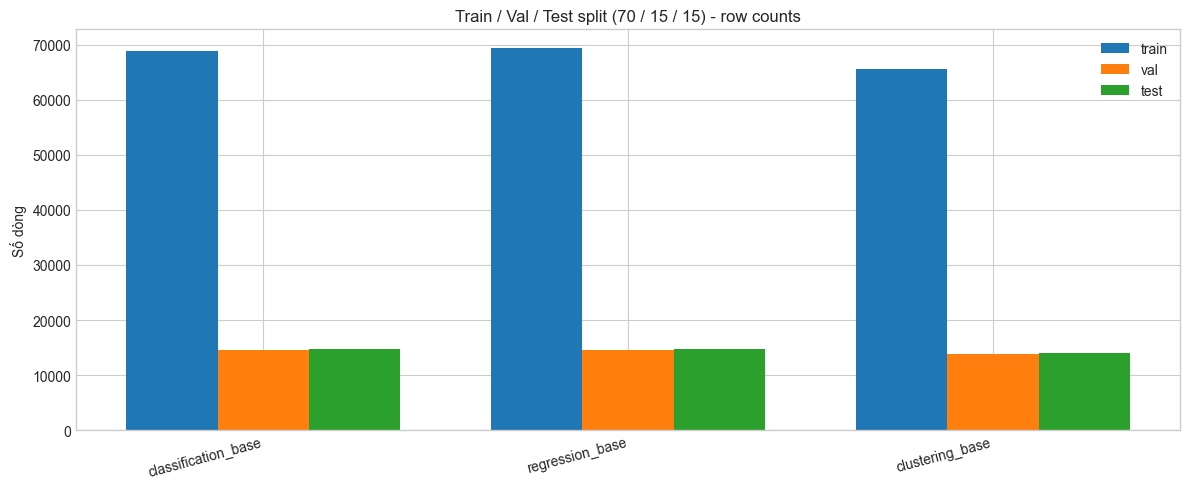

In [63]:
# Command 25 - Train / Validation / Test Split 70/15/15
SPLIT_SEED = 42
SPLIT_RATIOS = [0.70, 0.15, 0.15]

# Classification
train_clf, val_clf, test_clf = classification_base_df.randomSplit(SPLIT_RATIOS, seed=SPLIT_SEED)

# Regression
train_reg, val_reg, test_reg = regression_base_df.randomSplit(SPLIT_RATIOS, seed=SPLIT_SEED)

# Clustering
train_clus, val_clus, test_clus = clustering_base_df.randomSplit(SPLIT_RATIOS, seed=SPLIT_SEED)

# ── Summary ──────────────────────────────────────────────────────────────
split_summary_rows = []
for dataset_name, train_df, val_df, test_df in [
    ("classification_base", train_clf, val_clf, test_clf),
    ("regression_base",     train_reg, val_reg, test_reg),
    ("clustering_base",     train_clus, val_clus, test_clus),
]:
    total = train_df.count() + val_df.count() + test_df.count()
    split_summary_rows.append((
        dataset_name,
        train_df.count(), val_df.count(), test_df.count(), total,
        f"{train_df.count()/total*100:.1f}%",
        f"{val_df.count()/total*100:.1f}%",
        f"{test_df.count()/total*100:.1f}%",
    ))

split_summary_pdf = pd.DataFrame(
    split_summary_rows,
    columns=["dataset", "train", "val", "test", "total", "train_%", "val_%", "test_%"],
)
print(split_summary_pdf.to_string(index=False))

# Bar chart
x = split_summary_pdf["dataset"]
x_pos = range(len(x))
width = 0.25
plt.figure(figsize=(12, 5))
plt.bar([p - width for p in x_pos], split_summary_pdf["train"], width=width, label="train")
plt.bar(x_pos,                       split_summary_pdf["val"],   width=width, label="val")
plt.bar([p + width for p in x_pos], split_summary_pdf["test"],  width=width, label="test")
plt.xticks(x_pos, x, rotation=15, ha="right") # type: ignore
plt.title("Train / Val / Test split (70 / 15 / 15) - row counts")
plt.ylabel("Số dòng")
plt.legend()
plt.tight_layout()
plt.show()

**[C6-3] Post-Split Median Imputation (fit on train only)**

- Sau khi split, các cột numeric có thể còn NULL (do invalid values đã set về `None` ở bước cleaning).
- Median được tính **chỉ trên tập train** → apply vào cả train / val / test.
  Đây là cách đúng để tránh data leakage: val/test không được biết thông tin từ chính nó.
- Các cột cần impute:
  - `classification_base`: `order_gmv`, `payment_total_value`
  - `regression_base`: `order_gmv`, `order_freight_value`, `avg_product_weight_g`
  - `clustering_base`: `monetary_value` (từ RFM)
- Hàm `post_split_fill(train, val, test, col)` tính median từ train rồi broadcast sang cả 3 split.


In [64]:
# Command 26 - Post-split median imputation (fit on train only)

def post_split_fill(train_df, val_df, test_df, col_name):
    """Tính median từ train, fill NULL trong cả 3 split."""
    median_val = train_df.approxQuantile(col_name, [0.5], 0.001)[0]
    fill_expr = F.coalesce(F.col(col_name), F.lit(median_val))
    return (
        train_df.withColumn(col_name, fill_expr),
        val_df.withColumn(col_name, fill_expr),
        test_df.withColumn(col_name, fill_expr),
    )

# Classification base
for col in ["order_gmv", "payment_total_value"]:
    train_clf, val_clf, test_clf = post_split_fill(train_clf, val_clf, test_clf, col)

# Regression base
for col in ["order_gmv", "order_freight_value", "avg_product_weight_g"]:
    train_reg, val_reg, test_reg = post_split_fill(train_reg, val_reg, test_reg, col)

# Clustering base (monetary_value từ RFM)
for col in ["monetary_value"]:
    train_clus, val_clus, test_clus = post_split_fill(train_clus, val_clus, test_clus, col)

# Verify: kiểm tra null count sau imputation
impute_check_rows = []
for name, df in [
    ("train_clf", train_clf), ("val_clf", val_clf), ("test_clf", test_clf),
    ("train_reg", train_reg), ("val_reg", val_reg), ("test_reg", test_reg),
    ("train_clus", train_clus), ("val_clus", val_clus), ("test_clus", test_clus),
]:
    null_count = sum(
        df.filter(F.col(c).isNull()).count()
        for c in df.columns if c not in ["order_id", "customer_unique_id", "order_purchase_timestamp",
                                          "customer_unique_id", "customer_state", "seller_state_set",
                                          "category_set", "payment_type_set"]
    )
    impute_check_rows.append((name, df.count(), null_count))

impute_check_pdf = pd.DataFrame(impute_check_rows, columns=["split", "rows", "null_count_numeric"])
print(impute_check_pdf.to_string(index=False))

     split  rows  null_count_numeric
 train_clf 68887                1591
   val_clf 14546                 282
  test_clf 14734                 303
 train_reg 69294                   1
   val_reg 14611                   0
  test_reg 14761                   0
train_clus 65592                   0
  val_clus 13799                   0
 test_clus 13967                   0


**[C6-4] Định nghĩa danh sách output và ghi parquet**

- `silver_outputs`: các bảng clean và analytical cơ bản → lưu vào `data/processed/silver/`.
  Lớp silver là dữ liệu đã làm sạch, có thể dùng cho nhiều mục đích khác nhau.
- `gold_outputs`: các base dataset **đã split + imputed** → lưu vào `data/processed/gold/`.
  Naming convention: `<dataset>_train`, `<dataset>_val`, `<dataset>_test`.
- `als_base` và `fpgrowth_base` lưu nguyên (không split).
- Dùng `mode('overwrite')` để overwrite nếu đã tồn tại (idempotent pipeline).
- In `save_summary_pdf` để kiểm tra toàn bộ path đã ghi.


In [65]:
silver_outputs = {
    "customers": customers_clean,
    "orders": orders_clean,
    "order_items": order_items_clean,
    "order_payments": order_payments_clean,
    "order_reviews": reviews_clean,
    "products": products_clean,
    "sellers": sellers_clean,
    "geolocation": geolocation_clean,
    "category_translation": category_translation_clean,
    "master_orders": master_orders_df,
    "customer_level_analytical": customer_level_analytical_df,
    "product_level_summary": product_level_summary_df,
    "seller_level_summary": seller_level_summary_df,
    "rfm": rfm_df,
}

gold_outputs = {
    # Supervised — split train / val / test
    "classification_base_train": train_clf,
    "classification_base_val":   val_clf,
    "classification_base_test":  test_clf,
    "regression_base_train": train_reg,
    "regression_base_val":   val_reg,
    "regression_base_test":  test_reg,
    "clustering_base_train": train_clus,
    "clustering_base_val":   val_clus,
    "clustering_base_test":  test_clus,
    # Unsupervised — không split
    "als_base":      als_base_df,
    "fpgrowth_base": fpgrowth_base_df,
}

for dataset_name, df in silver_outputs.items():
    df.write.mode("overwrite").parquet(str(SILVER_DIR / dataset_name))

for dataset_name, df in gold_outputs.items():
    df.write.mode("overwrite").parquet(str(GOLD_DIR / dataset_name))

save_summary_pdf = pd.DataFrame(
    [("silver", name, str(SILVER_DIR / name)) for name in silver_outputs.keys()]
    + [("gold", name, str(GOLD_DIR / name)) for name in gold_outputs.keys()],
    columns=["layer", "dataset_name", "parquet_path"],
).sort_values(["layer", "dataset_name"]).reset_index(drop=True)
print(save_summary_pdf.to_string(index=False))

 layer              dataset_name                                                                                                       parquet_path
  gold                  als_base                    /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/processed/gold/als_base
  gold  classification_base_test    /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/processed/gold/classification_base_test
  gold classification_base_train   /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/processed/gold/classification_base_train
  gold   classification_base_val     /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/processed/gold/classification_base_val
  gold      clustering_base_test        /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/processed/gold/clustering_base_test
  gold     clustering_base_train       /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/p

### Kết luận cuối pha preprocessing


**[C7-1] Feature Catalog — danh mục các nhóm feature**

- Tổng hợp 10 nhóm feature candidate phục vụ cho giai đoạn feature engineering:
  customer, order, product, seller, payment, time, geo, review text, RFM, basket.
- Đây là danh mục tham chiếu, không phải bảng modeling.


In [66]:
# Command 26 - Tổng hợp feature catalog, dataset mapping và kết luận preprocessing
feature_catalog_pdf = pd.DataFrame(
    [
        ("customer_features", "total_orders, customer_recency_days, customer_state, avg_items_per_order"),
        ("order_features", "items_per_order, unique_products_per_order, unique_categories_per_order, order_gmv"),
        ("product_features", "avg_price, gross_revenue, product_category_name_enriched, product_weight_g"),
        ("seller_features", "seller_state, gross_revenue, avg_freight_value, same_state_ratio"),
        ("payment_features", "payment_total_value, max_payment_installments, payment_record_count, payment_type_set"),
        ("time_features", "order month, weekday, recency_days, seasonal bucket"),
        ("geo_features", "customer_state, customer_zip_lat, same_state_any_seller_flag"),
        ("review_text_features", "has_review_comment, max_review_comment_length, TF-IDF readiness"),
        ("rfm_features", "recency_days, frequency_orders, monetary_value"),
        ("basket_interaction_features", "basket_product_ids, implicit_rating, purchase_count"),
    ],
    columns=["feature_group", "candidate_features"],
)



**[C7-2] Model-Dataset Mapping — ánh xạ mô hình → dataset**

- Mỗi model family được ánh xạ rõ ràng đến parquet path và ghi chú quan trọng.
- Giúp tránh dùng sai dataset cho sai bài toán (ví dụ: dùng review outcome cho early prediction).


In [67]:
model_dataset_map_pdf = pd.DataFrame(
    [
        ("classification_review", "gold/classification_base", "Target gợi ý: is_low_review; loại bỏ review text và delivery outcomes cho dự báo sớm"),
        ("classification_churn_proxy", "silver/customer_level_analytical + silver/rfm", "Định nghĩa churn theo khoảng không mua hàng đủ dài"),
        ("regression_order_value", "gold/regression_base", "Grain order-level; target gợi ý: order_gmv hoặc order_freight_value"),
        ("clustering_customer", "gold/clustering_base", "Dùng RFM và activity features ở grain customer-level"),
        ("als_recommendation", "gold/als_base", "Implicit feedback từ purchase_count và total_spend"),
        ("fp_growth", "gold/fpgrowth_base", "Danh sách item theo order_id"),
    ],
    columns=["model_family", "recommended_dataset", "note"],
)



**[C7-3] Data Issue Summary — tổng hợp rủi ro dữ liệu**

- Tóm tắt 5 nhóm vấn đề chất lượng dữ liệu đã xử lý trong notebook này:
  1. **Null values**: text, timestamp và numeric attributes.
  2. **Duplicates**: geolocation, reviews và một số bảng con.
  3. **Invalid values**: giá âm, score ngoài miền, kích thước không hợp lệ.
  4. **Leakage risk**: review/delivery columns cho dự báo sớm.
  5. **Grain risk**: join trực tiếp bảng 1-n gây row explosion.


In [68]:
data_issue_summary_pdf = pd.DataFrame(
    [
        ("Null values", "Review text, logistics timestamps và product attributes thiếu cục bộ"),
        ("Duplicates", "Geolocation, reviews và một số bảng con cần deduplicate trước khi join"),
        ("Invalid values", "Numeric <= 0, review score ngoài miền, dimension không hợp lệ"),
        ("Leakage risk", "Review và delivery columns nếu dùng cho dự báo sớm"),
        ("Grain risk", "Join trực tiếp items/payments/reviews vào orders gây row explosion"),
    ],
    columns=["issue_group", "summary"],
)

print(feature_catalog_pdf.to_string(index=False))
print(model_dataset_map_pdf.to_string(index=False))
print(data_issue_summary_pdf.to_string(index=False))


              feature_group                                                                    candidate_features
          customer_features              total_orders, customer_recency_days, customer_state, avg_items_per_order
             order_features    items_per_order, unique_products_per_order, unique_categories_per_order, order_gmv
           product_features            avg_price, gross_revenue, product_category_name_enriched, product_weight_g
            seller_features                      seller_state, gross_revenue, avg_freight_value, same_state_ratio
           payment_features payment_total_value, max_payment_installments, payment_record_count, payment_type_set
              time_features                                   order month, weekday, recency_days, seasonal bucket
               geo_features                          customer_state, customer_zip_lat, same_state_any_seller_flag
       review_text_features                       has_review_comment, max_review_comment